In [1]:
import numpy as np
import pandas as pd

In [2]:
def read_file(file_path):
    
    df = pd.read_csv(file_path)
    return df

In [3]:
file_path = "insurance.csv"
df = read_file(file_path)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
n_unique = df.nunique()
n_unique

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [8]:
dtypes = df.dtypes
dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [11]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].astype('category')
df[cat_cols].dtypes

Series([], dtype: object)

In [12]:
dtypes = df.dtypes
n_unique = df.nunique()
pd.DataFrame({'dtypes': dtypes, 'n_unique': n_unique}).T

,age,sex,bmi,children,smoker,region,charges
dtypes,int64,category,float64,int64,category,category,float64
n_unique,47,2,548,6,2,4,1337


In [14]:
null_values = df.isnull().sum()
null_values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [15]:
num_cols = df.select_dtypes("number").columns
num_cols

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [16]:
fences = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    fences.append([col, lower_fence, upper_fence])
    
result = pd.DataFrame(
    fences, 
    columns = ['Column', 'Lower Fence', 'Upper Fence']
) 

display(result)   

,Column,Lower Fence,Upper Fence
0,age,-9.000000,87.000000
1,bmi,13.700000,47.290000
2,children,-3.000000,5.000000
3,charges,-13109.150897,34489.350562


In [17]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    lower_outliers = df[df[col]<lower_fence][col].values
    upper_outliers = df[df[col]>upper_fence][col].values
    
    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)

In [18]:
df.duplicated().sum()

np.int64(1)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [22]:
cat_cols = df.select_dtypes("category").columns
fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[{'type': 'domain'}] * 3],
    subplot_titles=cat_cols
)

for i, col in enumerate(cat_cols):

    unique = df[col].value_counts()

    counts = unique.values
    category_names = unique.index

    fig.add_trace(
        go.Pie(
            values=counts,
            labels=category_names,
            textinfo='percent'
        ),
        row=i//3+1,
        col=i%3+1
    )

fig.update_layout(
    title='Categorical Variables Distribution'
)

fig.show()

In [25]:
num_cols = df.select_dtypes("number").columns
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=num_cols
)

for i, col in enumerate(num_cols):

    fig.add_trace(
        go.Histogram(
            x=df[col],
            name=col
        ),
        row=i//2 + 1,
        col=i%2 + 1
    )

fig.update_layout(
    title='Distribution of Numerical Variables',
    showlegend=False,
    height=600
)

fig.show()

In [24]:
outlier_cols = ['age', 'bmi', 'charges']

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=outlier_cols
)

for i, col in enumerate(outlier_cols):

    fig.add_trace(
        go.Box(
            y=df[col],
            name=col,
            boxpoints='outliers'
        ),
        row=1,
        col=i+1
    )

fig.update_layout(
    title='Outlier Detection',
    showlegend=False
)

fig.show()

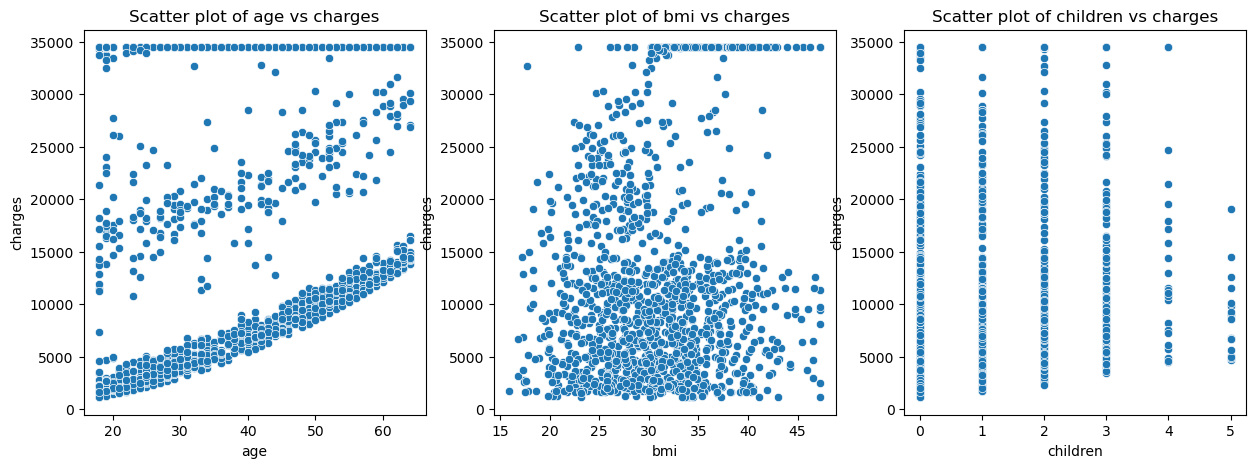

In [31]:
numerical = ['age', 'bmi', 'children']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(data = df, x=col, y='charges')
    plt.title(f'Scatter plot of {col} vs charges')
    
#plt.tight_layout()
plt.show()    

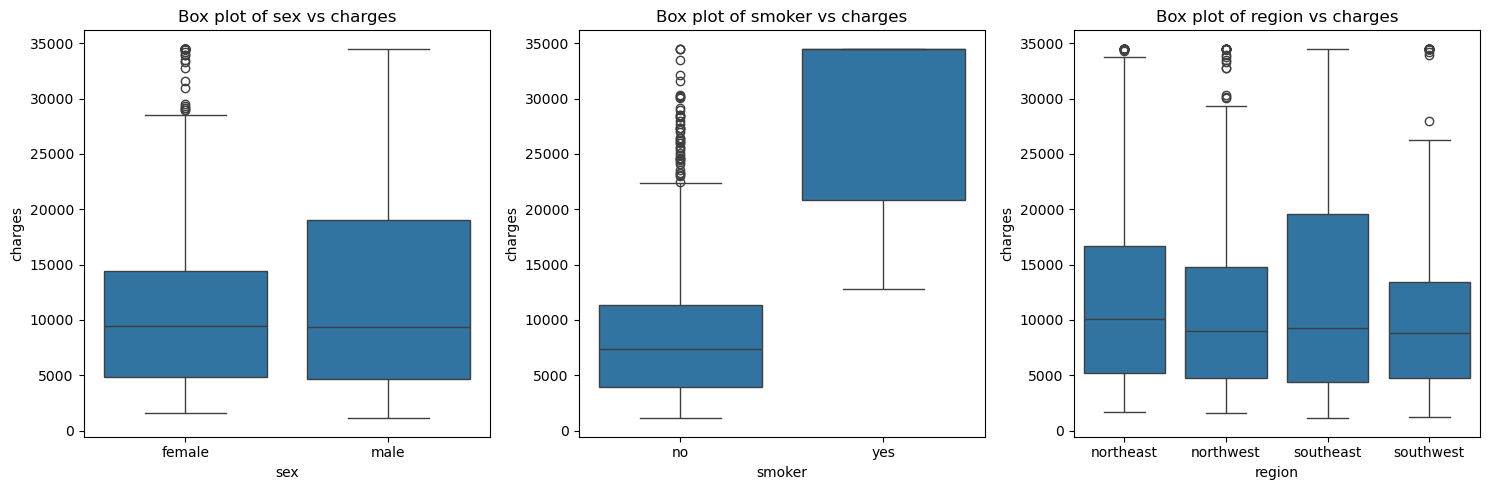

In [32]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x=col, y='charges')
    plt.title(f'Box plot of {col} vs charges')
    
plt.tight_layout()    
plt.show()

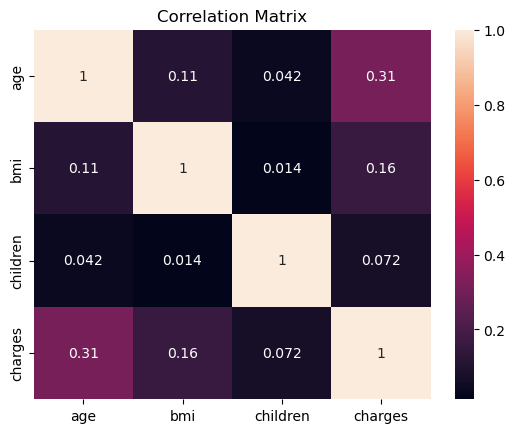

In [36]:
corr= df[num_cols].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

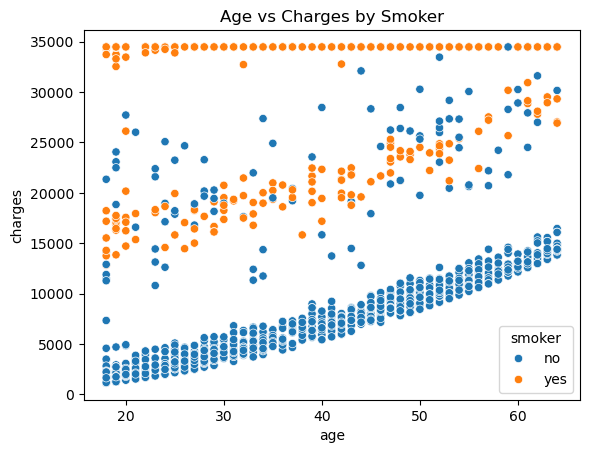

In [38]:
sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    hue='smoker' 
)

plt.title('Age vs Charges by Smoker')
plt.show()

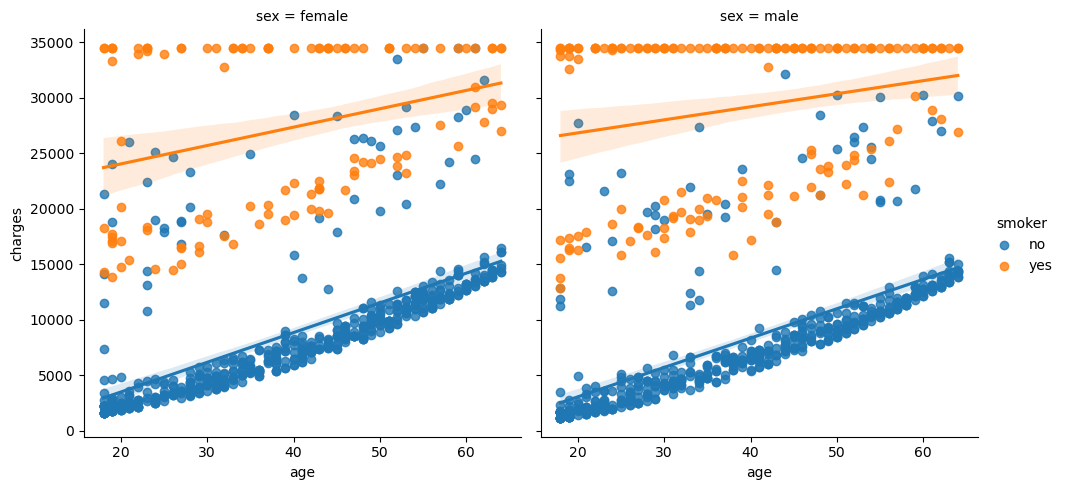

In [39]:
sns.lmplot(
    data=df,
    x='age',
    y='charges',
    hue='smoker',
    col='sex'
)

plt.show()

In [41]:
x = df.drop("charges", axis=1)
y = df["charges"]

In [42]:
from sklearn.preprocessing import MinMaxScaler
num_col = x.select_dtypes("number").columns
scaler = MinMaxScaler()
scaler.fit(x[num_col])
x[num_col] = scaler.transform(x[num_col])

In [43]:
from category_encoders import OneHotEncoder
str_cols =['sex', 'smoker', 'region']
encoder = OneHotEncoder(cols= str_cols , drop_invariant=True)
x = encoder.fit_transform(x) 

In [44]:
x.head()

,age,sex_1,sex_2,bmi,children,smoker_1,smoker_2,region_1,region_2,region_3,region_4
0,0.021739,1,0,0.381104,0.0,1,0,1,0,0,0
1,0.000000,0,1,0.568465,0.2,0,1,0,1,0,0
2,0.217391,0,1,0.543888,0.6,0,1,0,1,0,0
3,0.326087,0,1,0.215289,0.0,0,1,0,0,1,0
4,0.304348,0,1,0.412384,0.0,0,1,0,0,1,0
